In [ ]:
# Iris Flower Classification
# OASIS INFOBYTE - Data Science Task 1

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
# Load the Iris dataset

iris = load_iris()

# Create a DataFrame
df = pd.DataFrame(
    iris.data,
    columns=iris.feature_names
)

# Add the target column
df["target"] = iris.target

# Add species names
df["species"] = df["target"].map({
    0: "Setosa",
    1: "Versicolor",
    2: "Virginica"
})

# Display the first 5 rows
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,species
0,5.1,3.5,1.4,0.2,0,Setosa
1,4.9,3.0,1.4,0.2,0,Setosa
2,4.7,3.2,1.3,0.2,0,Setosa
3,4.6,3.1,1.5,0.2,0,Setosa
4,5.0,3.6,1.4,0.2,0,Setosa


In [3]:
# Explore the dataset

print("Dataset Shape:", df.shape)

print("\nDataset Information:")
df.info()

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDescriptive Statistics:")
df.describe()

Dataset Shape: (150, 6)

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   target             150 non-null    int64  
 5   species            150 non-null    object 
dtypes: float64(4), int64(1), object(1)
memory usage: 7.2+ KB

Missing Values:
sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
target               0
species              0
dtype: int64

Descriptive Statistics:


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333,1.000000
std,0.828066,0.435866,1.765298,0.762238,0.819232
min,4.300000,2.000000,1.000000,0.100000,0.000000
25%,5.100000,2.800000,1.600000,0.300000,0.000000
50%,5.800000,3.000000,4.350000,1.300000,1.000000
75%,6.400000,3.300000,5.100000,1.800000,2.000000
max,7.900000,4.400000,6.900000,2.500000,2.000000


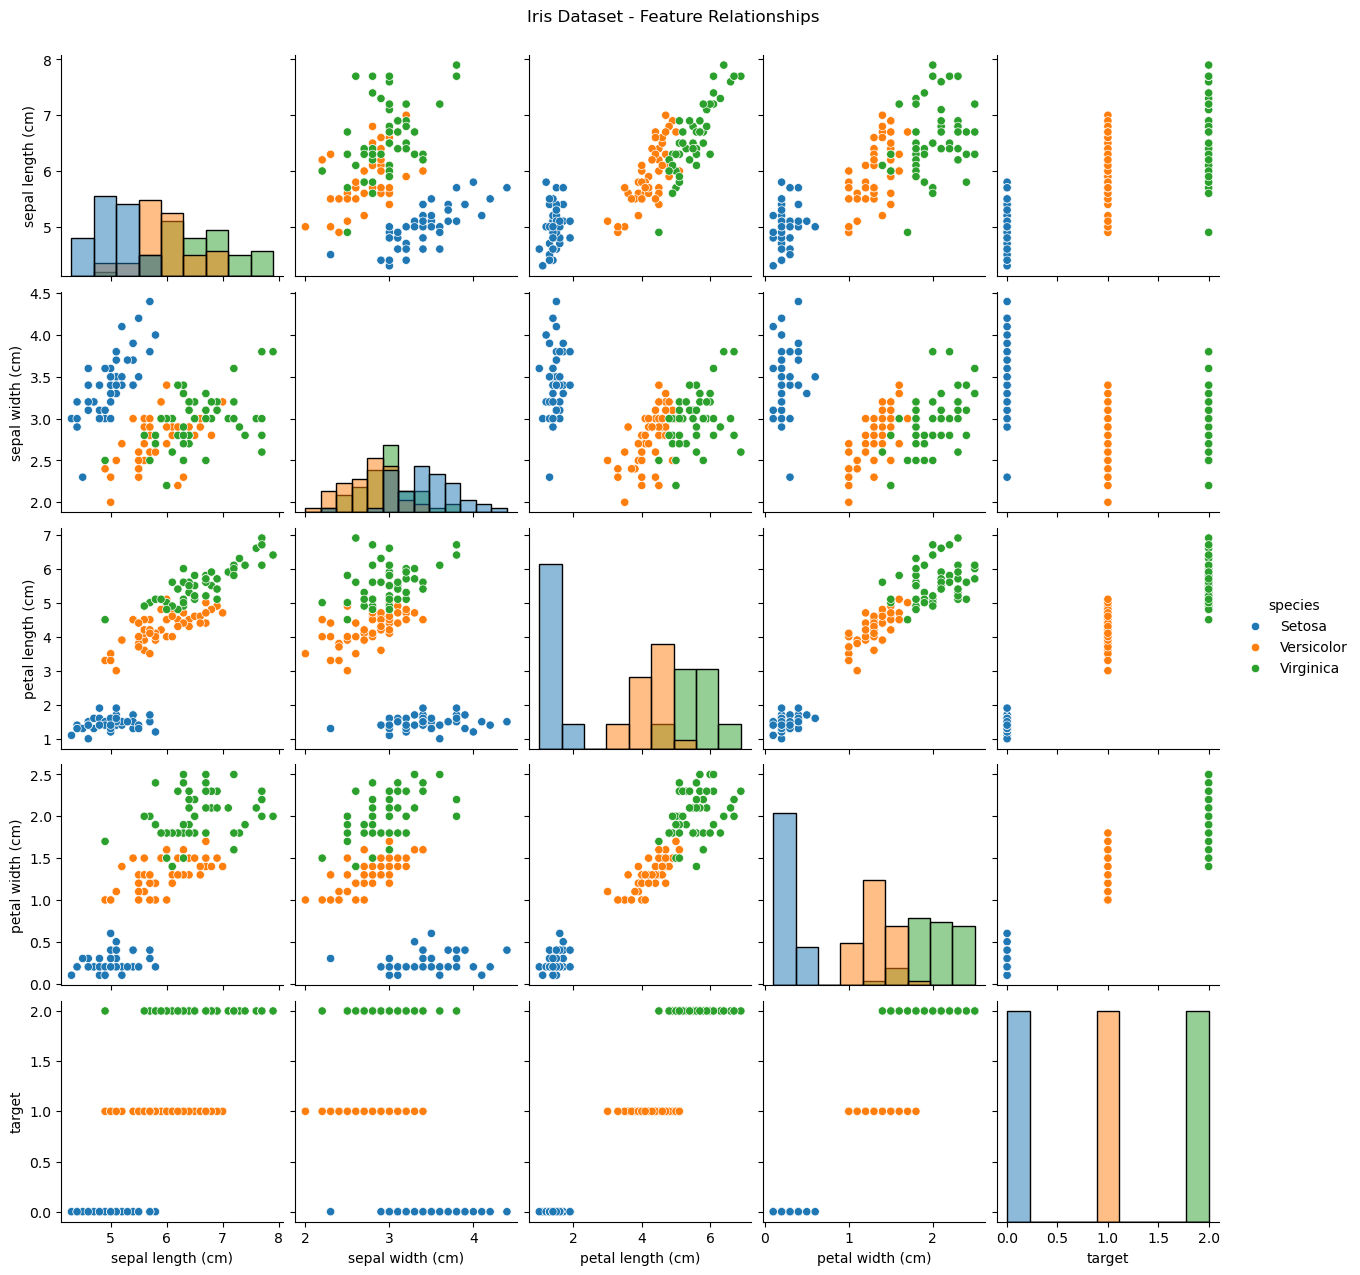

In [4]:
# Pairplot to visualize relationships between features

sns.pairplot(
    df,
    hue="species",
    diag_kind="hist"
)

plt.suptitle("Iris Dataset - Feature Relationships", y=1.02)
plt.show()

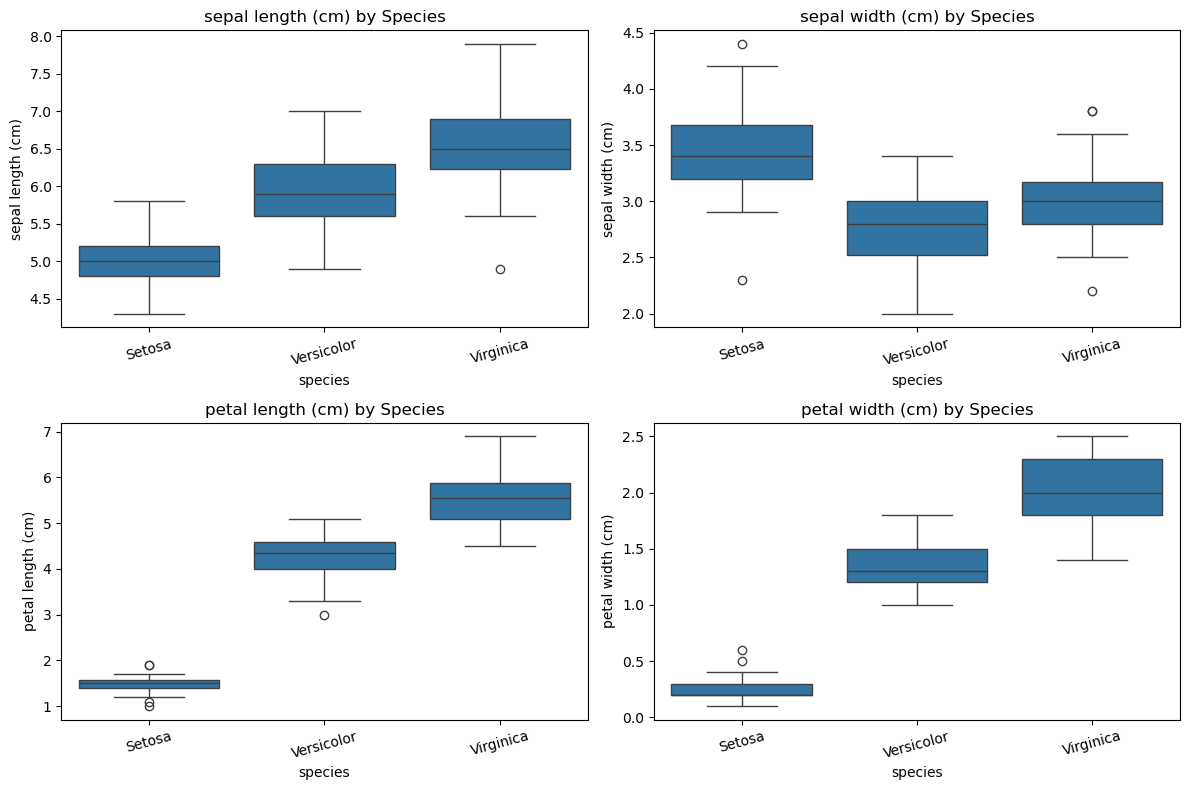

In [5]:
# Box plots to identify feature distributions and outliers

features = iris.feature_names

plt.figure(figsize=(12, 8))

for i, feature in enumerate(features, 1):
    plt.subplot(2, 2, i)
    sns.boxplot(data=df, x="species", y=feature)
    plt.title(f"{feature} by Species")
    plt.xticks(rotation=15)

plt.tight_layout()
plt.show()

In [6]:
# Feature selection

# Select input features
X = df[iris.feature_names]

# Select target variable
y = df["target"]

print("Features used for classification:")
print(X.columns.tolist())

print("\nTarget classes:")
print(iris.target_names)

Features used for classification:
['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']

Target classes:
['setosa' 'versicolor' 'virginica']


In [7]:
# Split the dataset into training and testing sets

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 120
Testing samples: 30


In [8]:
# Import classification models

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier

# Create the models
models = {
    "Logistic Regression": LogisticRegression(max_iter=200),
    "K-Nearest Neighbors": KNeighborsClassifier(n_neighbors=5),
    "Decision Tree": DecisionTreeClassifier(random_state=42)
}

# Train each model
for name, model in models.items():
    model.fit(X_train, y_train)
    print(f"{name} trained successfully!")


Logistic Regression trained successfully!
K-Nearest Neighbors trained successfully!
Decision Tree trained successfully!


In [9]:
# Evaluate model accuracy

from sklearn.metrics import accuracy_score

results = {}

for name, model in models.items():
    y_pred = model.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    results[name] = accuracy

print("Model Accuracy:")
for name, accuracy in results.items():
    print(f"{name}: {accuracy:.2%}")

Model Accuracy:
Logistic Regression: 96.67%
K-Nearest Neighbors: 100.00%
Decision Tree: 93.33%


Logistic Regression

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      0.90      0.95        10
   virginica       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30



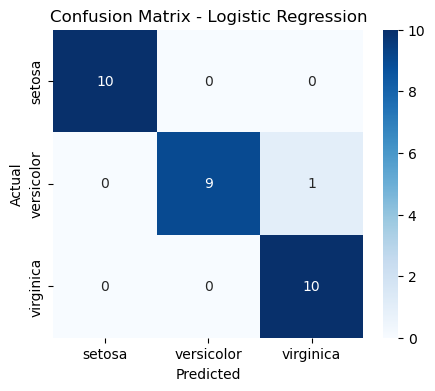

K-Nearest Neighbors

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00        10
   virginica       1.00      1.00      1.00        10

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



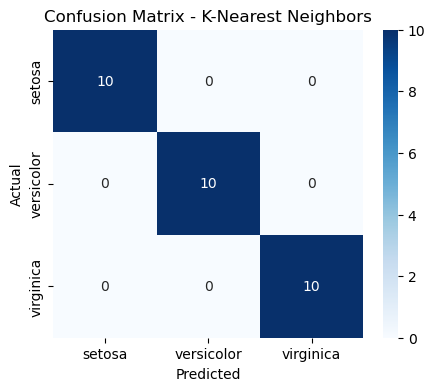

Decision Tree

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.90      0.90      0.90        10
   virginica       0.90      0.90      0.90        10

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30



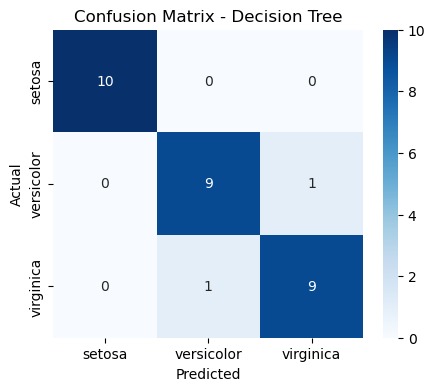

In [10]:
# Detailed evaluation of each model

from sklearn.metrics import confusion_matrix, classification_report

for name, model in models.items():
    
    # Make predictions
    y_pred = model.predict(X_test)
    
    print("=" * 60)
    print(name)
    print("=" * 60)
    
    # Classification report
    print("\nClassification Report:")
    print(
        classification_report(
            y_test,
            y_pred,
            target_names=iris.target_names
        )
    )
    
    # Confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    
    plt.figure(figsize=(5, 4))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=iris.target_names,
        yticklabels=iris.target_names
    )
    
    plt.title(f"Confusion Matrix - {name}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

In [11]:
# Compare model performance

results_df = pd.DataFrame({
    "Model": results.keys(),
    "Accuracy": results.values()
})

results_df = results_df.sort_values(
    by="Accuracy",
    ascending=False
).reset_index(drop=True)

results_df["Accuracy (%)"] = (
    results_df["Accuracy"] * 100
).round(2)

results_df

,Model,Accuracy,Accuracy (%)
0,K-Nearest Neighbors,1.000000,100.00
1,Logistic Regression,0.966667,96.67
2,Decision Tree,0.933333,93.33


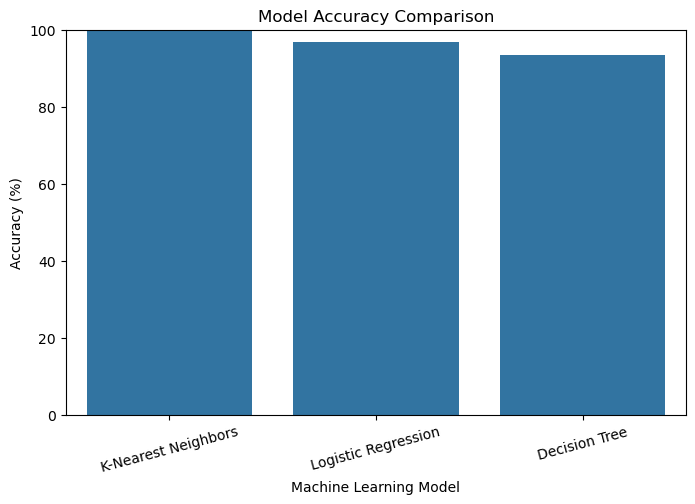

In [12]:
# Visualize model accuracy

plt.figure(figsize=(8, 5))

sns.barplot(
    data=results_df,
    x="Model",
    y="Accuracy (%)"
)

plt.title("Model Accuracy Comparison")
plt.xlabel("Machine Learning Model")
plt.ylabel("Accuracy (%)")
plt.ylim(0, 100)
plt.xticks(rotation=15)
plt.show()

In [14]:
# Find the best performing model

best_model_name = results_df.loc[0, "Model"]
best_accuracy = results_df.loc[0, "Accuracy (%)"]

print("Best Model:", best_model_name)
print(f"Best Accuracy: {best_accuracy:.2f}%")

Best Model: K-Nearest Neighbors
Best Accuracy: 100.00%


In [16]:
sample = pd.DataFrame(
    [[5.1, 3.5, 1.4, 0.2]],
    columns=iris.feature_names
)

prediction = best_model.predict(sample)

predicted_species = iris.target_names[prediction[0]]

print("Predicted Flower Species:", predicted_species.title())

Predicted Flower Species: Setosa
